This project focuses on predicting student academic performance using machine learning techniques. The dataset contains information about attendance percentage, homework completion, study hours per week, and midterm scores. These factors were analysed to identify how they affect whether a student passes or fails.

Different visualisation techniques such as heatmaps, scatter plots, boxplots, pairplots, and confusion matrices were used to understand the relationships between the variables. Machine learning models including Logistic Regression, Decision Tree, Random Forest, KNN, and SVM were trained and tested to predict student outcomes.

The main aim of this project is to identify the key factors that influence student success and evaluate how accurately machine learning models can predict academic performance.

In [39]:
!pip install pandas numpy matplotlib seaborn scikit-learn

IMPORT IMPORTANT **FUNCTIONS**

In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**IMPORT AND UNDERSTAND THE FILE**

In [41]:

df = pd.read_csv ("/Pass-Fail Data (1).csv")

In [42]:
print(df.head())

   student_id  attendance_pct  homework_pct  midterm_score  \
0           1              95            92             88   
1           2              88            85             79   
2           3              60            55             58   
3           4              72            70             65   
4           5              40            45             50   

   study_hours_per_week  pass  
0                    12     1  
1                    10     1  
2                     4     0  
3                     6     1  
4                     3     0  


In [43]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB
None


In [44]:
print(df.isnull().sum())

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64


In [45]:
print(df.describe())

       student_id  attendance_pct  homework_pct  midterm_score  \
count  100.000000      100.000000     100.00000     100.000000   
mean    50.500000       69.520000      69.03000      68.780000   
std     29.011492       17.651783      17.01304      14.717254   
min      1.000000       30.000000      35.00000      42.000000   
25%     25.750000       55.000000      55.00000      56.000000   
50%     50.500000       72.500000      70.00000      68.000000   
75%     75.250000       85.000000      85.00000      82.000000   
max    100.000000       95.000000      96.00000      97.000000   

       study_hours_per_week        pass  
count             100.00000  100.000000  
mean                7.28000    0.600000  
std                 3.62115    0.492366  
min                 2.00000    0.000000  
25%                 4.00000    0.000000  
50%                 7.00000    1.000000  
75%                10.00000    1.000000  
max                15.00000    1.000000  


**EXPLORATORY DATA ANALYSIS**

**ATTENDANCE VS PASS**

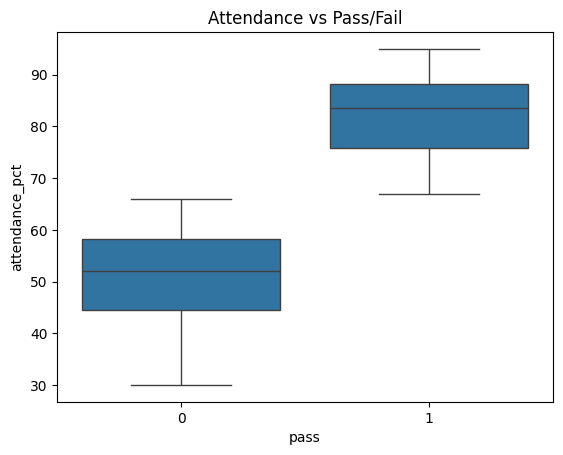

In [46]:
sns.boxplot(x='pass', y= 'attendance_pct', data=df)
plt.title("Attendance vs Pass/Fail")
plt.show()

/tmp/ipykernel_673/2866177367.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


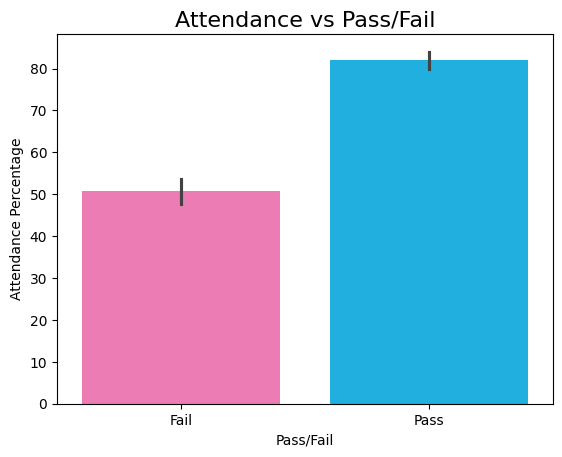

In [47]:
sns.barplot(
    x='pass',
    y='attendance_pct',
    data=df,
    palette=['#ff69b4', '#00bfff']
)

plt.title("Attendance vs Pass/Fail", fontsize=16)
plt.xlabel("Pass/Fail")
plt.ylabel("Attendance Percentage")

plt.xticks([0,1], ['Fail', 'Pass'])

plt.show()

The boxplot shows the relationship between attendance percentage and whether students passed or failed. Students who passed the course generally had much higher attendance compared to students who failed. Most students who passed had attendance percentages between about 75% and 85%, while students who failed mostly had attendance percentages between 45% and 55%.

The graph clearly suggests that students who attend classes more regularly are more likely to perform well academically and pass their courses. In contrast, students with lower attendance levels were more likely to fail. This may be because students who attend classes consistently are able to understand lessons better, participate in classroom activities, and keep up with coursework and assignments.

The difference between the two groups is quite noticeable, showing that attendance plays an important role in academic success. The results also suggest that attendance percentage is a strong feature for predicting student performance in the machine learning classification model.

Overall, the visualization highlights the importance of regular class attendance and shows that students who are more present in class tend to achieve better academic outcomes.

**HOMEWORK vs PASS/FAIL**

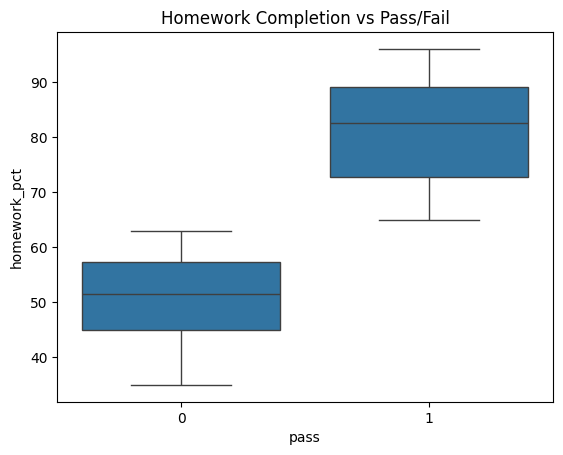

In [48]:
sns.boxplot(x='pass', y= 'homework_pct', data=df)
plt.title("Homework Completion vs Pass/Fail")
plt.show()

/tmp/ipykernel_673/2169050557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


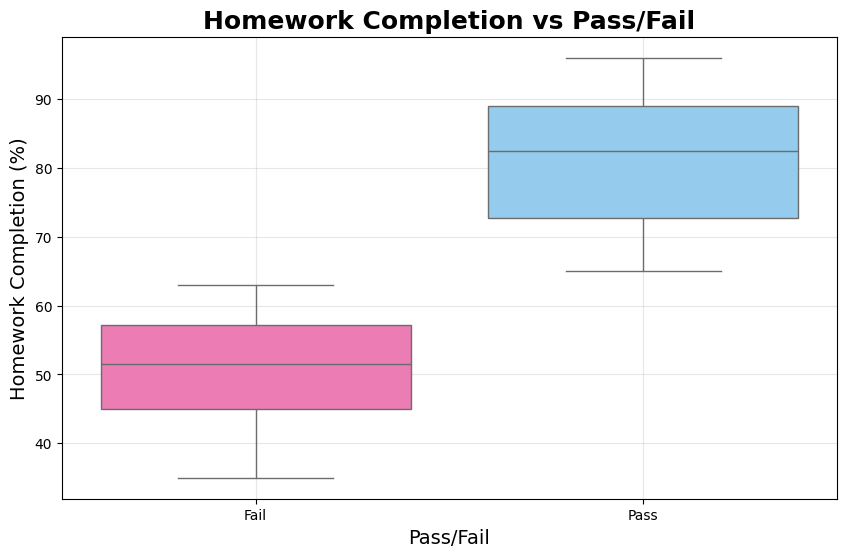

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='pass',
    y='homework_pct',
    data=df,
    palette=['#ff69b4', '#87cefa']
)

plt.title(
    "Homework Completion vs Pass/Fail",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Pass/Fail", fontsize=14)
plt.ylabel("Homework Completion (%)", fontsize=14)

plt.xticks([0,1], ['Fail', 'Pass'])

plt.grid(alpha=0.3)

plt.show()

The boxplot shows the relationship between homework completion and whether students passed or failed the course. It compares the homework completion percentages of students in both groups and helps identify patterns in academic performance.

Students who passed the course, represented by the value (1), generally had much higher homework completion percentages than students who failed, represented by the value (0). Most students who passed completed between 70% and 90% of their homework, while students who failed mostly completed between 45% and 55%. This clear difference suggests that students who consistently completed their homework were more likely to achieve successful academic outcomes.

The graph also shows that the median homework completion level for passing students is much higher than that of failing students. This means that, on average, students who passed were more consistent and committed to completing their assignments. In contrast, lower homework completion rates were associated with poorer academic performance and a higher likelihood of failing.

Additionally, there is very little overlap between the two groups in the boxplot, making the relationship between homework completion and pass/fail outcomes more noticeable. This indicates that homework completion is a strong factor influencing student success and may be an important feature in predicting academic performance using machine learning models.

Overall, the visualization demonstrates that regular homework completion plays a significant role in improving student performance and increasing the chances of passing the course.

**STUDY HOURS**

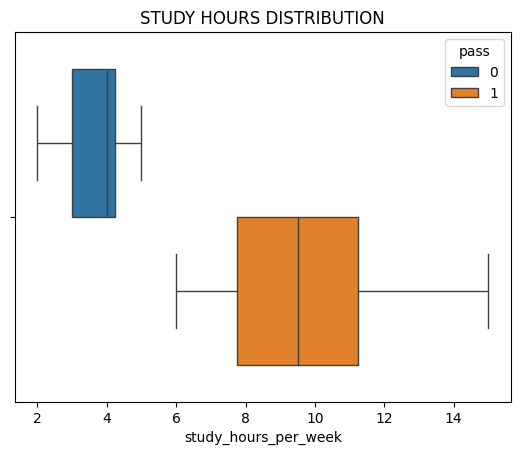

In [50]:
sns.boxplot(data=df, x='study_hours_per_week', hue = 'pass')
plt.title ("STUDY HOURS DISTRIBUTION")
plt.show()

/tmp/ipykernel_673/100552342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


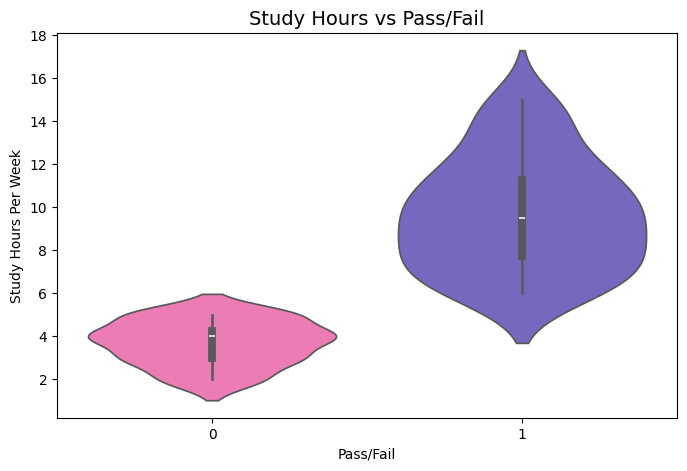

In [51]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='pass',
    y='study_hours_per_week',
    data=df,
    palette=['#ff69b4', '#6a5acd']
)

plt.title("Study Hours vs Pass/Fail", fontsize=14)
plt.xlabel("Pass/Fail")
plt.ylabel("Study Hours Per Week")

plt.show()

The violin plot was used to show the relationship between the number of study hours per week and whether students passed or failed. This type of chart helps display how the study hours are distributed for each group of students and makes it easier to compare their study habits.

The graph clearly shows that students who passed the course generally studied for more hours each week than students who failed. Most students who failed studied between 2 and 5 hours per week, with many of them studying around 3 to 4 hours. This suggests that lower study time may be linked to poorer academic performance.

In comparison, students who passed usually studied between 6 and 12 hours weekly, with the highest number of students studying around 8 to 10 hours. This indicates that students who spent more time studying were more likely to achieve better results and pass their courses.

The wider shape of the violin plot for passing students also shows that there was more variation in how long successful students studied. Some students studied slightly less, while others studied much more, but overall their study hours were still higher than those of failing students.

The boxplot inside the violin plot highlights the median study hours for both groups. The median study time for students who passed is much higher than that of students who failed. This further supports the idea that regular studying and spending more time learning can improve academic performance.

Another important observation is that there is very little overlap between the two groups. Most failing students studied for fewer hours, while most passing students studied for longer hours. This makes study hours an important factor in distinguishing between students who pass and students who fail.

Overall, the visualization suggests that study time plays a major role in student success. Students who dedicate more hours to studying are more likely to understand their subjects better, perform well in assessments, and successfully pass their courses.

**CORRELATION HEATMAP**

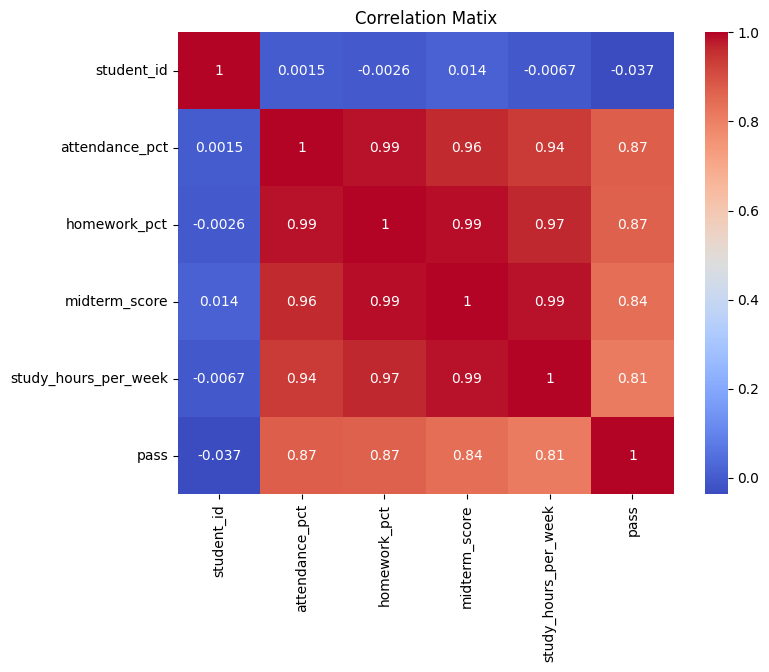

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matix")
plt.show()

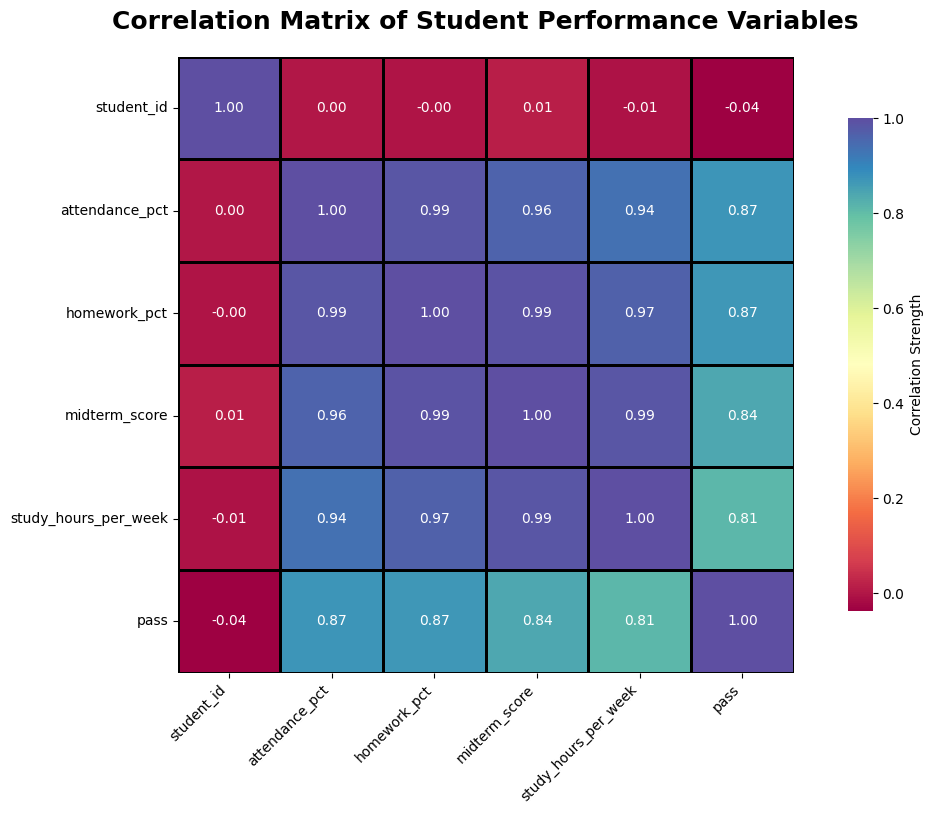

In [53]:
import matplotlib.patches as mpatches

plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    linewidths=2,
    linecolor='black',
    square=True,
    cbar_kws={
        'label': 'Correlation Strength',
        'shrink': 0.8
    }
)

# Title
plt.title(
    "Correlation Matrix of Student Performance Variables",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Axis labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)



plt.show()

The heatmap shows the relationship between all the numerical variables in the student performance dataset. It helps explain how strongly the variables are connected to one another and how they affect whether a student passes or fails. The different colours in the heatmap make the relationships easier to understand. Stronger relationships are shown with brighter and deeper colours, while weaker relationships appear lighter. The colour scale on the side acts as a guide for interpreting the strength of the correlations. Values closer to 1 mean there is a very strong positive relationship between two variables, while values closer to 0 mean there is little or no relationship.

From the heatmap, it can be seen that attendance percentage, homework completion percentage, midterm scores, and study hours per week all have strong positive relationships with the pass variable. This means that these factors are closely linked to student success. Students with higher attendance, better homework completion, higher midterm scores, and more study hours are more likely to pass their courses.

Attendance percentage and homework completion both have correlation values of approximately 0.87 with the pass outcome. This shows that students who attend classes regularly and complete their homework consistently have a much higher chance of passing. Good attendance allows students to participate in lessons and understand topics better, while homework completion helps reinforce learning outside the classroom. These two variables appear to be some of the strongest indicators of academic success in the dataset.

Midterm scores also show a strong positive relationship with pass/fail outcomes, with a correlation value of approximately 0.84. This means that students who perform well in their midterm examinations are generally more likely to pass overall. Midterm scores reflect a student’s understanding of the course content before the final outcome, making them an important factor in predicting academic performance.

Study hours per week have a correlation value of approximately 0.81 with the pass variable. Although this value is slightly lower than attendance and homework completion, it still represents a strong positive relationship. This suggests that students who spend more time studying are more likely to achieve better academic results. Consistent studying helps students improve understanding, revise important topics, and prepare effectively for assessments.

The heatmap also shows strong relationships between the independent variables themselves. For example, homework completion and attendance percentage have a very high correlation close to 0.99. This suggests that students who attend classes regularly are also more likely to complete their homework. Similarly, midterm scores and study hours show strong positive relationships, indicating that students who study more often tend to achieve higher assessment scores. These patterns demonstrate that positive academic behaviours are connected and often occur together.

In contrast, the student_id variable has correlation values very close to zero with all other variables. This indicates that student_id does not affect academic performance in any way. It is simply used to uniquely identify each student in the dataset and does not contribute to predicting pass or fail outcomes.

Overall, the heatmap clearly shows that academic engagement factors such as attendance, homework completion, study habits, and assessment performance play a major role in determining student success. The visualization highlights that students who actively participate in their studies and maintain consistent academic habits are more likely to pass. These findings also confirm that the selected variables are useful predictors for machine learning classification models used to predict student academic outcomes.

**MACHINE LEARNING**

**Prepare Data for Machine Learning**


Features and Target

In [54]:
X = df.drop(['pass', 'student_id'], axis=1)
Y = df['pass']

Split Data

80% training, 20% Testing

In [55]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

Scale Data

In [56]:
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

The preprocessing stage was an important step carried out before training the machine learning models. Preprocessing helps prepare the dataset in a clean and organized way so that the models can learn from the data more effectively and produce accurate predictions. Without proper preprocessing, machine learning models may perform poorly or produce unreliable results.

The first step in preprocessing involved separating the dataset into independent variables (features) and the dependent variable (target). The independent variables, represented as X, included attendance percentage, homework completion percentage, midterm scores, and study hours per week. These variables were selected because they are factors that may influence student academic performance. The dependent variable, represented as Y, was the pass/fail outcome, which is the value the machine learning models were trained to predict.

The student_id column was removed from the dataset because it only acts as a unique identifier for each student and does not contain meaningful academic information. Since student IDs do not affect whether a student passes or fails, including them in the model could reduce the effectiveness of the predictions and introduce unnecessary data into the analysis.

After separating the features and target variable, the dataset was divided into two groups known as the training set and testing set. The training set contained 80% of the data and was used to train the machine learning models. During this stage, the algorithms learned patterns and relationships between the features and the pass/fail outcomes. The remaining 20% of the data was used as the testing set. The testing set was not shown to the models during training and was instead used to evaluate how accurately the models could make predictions on unseen data.

Splitting the dataset into training and testing sets is important because it helps measure the real performance of the models. If the same data were used for both training and testing, the model might simply memorize the data instead of learning meaningful patterns. By testing the model on new data, it becomes easier to determine whether the model can generalize well and make reliable predictions in real-world situations.

A random_state value of 42 was also applied during the data splitting process. This ensures that the same random division of training and testing data is produced each time the code is run. Using a fixed random state improves consistency and reproducibility, meaning that the experiment can be repeated and produce the same results.

The next preprocessing step involved standardizing the data using the StandardScaler technique. Standardization is necessary because the variables in the dataset may have different numerical ranges. For example, attendance percentage and homework completion may have values ranging from 0 to 100, while study hours per week may have much smaller values. If the data is not scaled properly, variables with larger numerical values may dominate the learning process and negatively affect model performance.

StandardScaler works by transforming the data so that all features have a similar scale. This helps the machine learning algorithms process the data more fairly and improves their ability to identify meaningful patterns. Scaling is especially important for algorithms such as Logistic Regression because they are sensitive to differences in feature magnitude.

To avoid data leakage, the scaler was first fitted only on the training data and then applied to both the training and testing datasets. Data leakage occurs when information from the testing data is accidentally used during training, which can lead to unrealistic and misleading model performance. By fitting the scaler only on the training data, the integrity and fairness of the evaluation process were maintained.

Overall, the preprocessing stage played a major role in preparing the dataset for machine learning classification. The process ensured that the data was properly organized, divided into training and testing groups, and scaled consistently. These steps improved the efficiency, fairness, and reliability of the machine learning models used to predict student pass/fail outcomes.

**TRAIN MODELS**

**LOGISTIC REGRESSION**

In [57]:
lr = LogisticRegression()
lr.fit(X_train, Y_train)
lr_pred = lr.predict(X_test)

**DECISION TREE**

In [58]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train)
dt_pred = dt.predict(X_test)

**RANDOM FOREST**

In [59]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

In this study, three different machine learning classification models were used to predict whether a student would pass or fail. These models were Logistic Regression, Decision Tree Classifier, and Random Forest Classifier. Different models were selected because each one predicts outcomes in a different way. Using multiple models also made it possible to compare their accuracy, reliability, and overall performance to determine which model was most suitable for predicting student academic outcomes.

Logistic Regression was chosen because it is one of the simplest and most commonly used algorithms for classification problems where there are only two possible outcomes, such as pass or fail. The model works by calculating the probability that a student belongs to a particular class based on factors such as attendance percentage, homework completion, study hours, and midterm scores. If the probability is high, the model predicts that the student will pass; if the probability is low, the model predicts that the student will fail.

Logistic Regression is useful because it is fast, easy to understand, and produces clear results. It is often used as a starting or baseline model in machine learning projects because it allows researchers to measure how well more advanced models perform in comparison. Another advantage of Logistic Regression is that it works well when there is a direct or linear relationship between the input variables and the target outcome. In this project, it helped provide a simple and interpretable method for predicting student performance.

The Decision Tree Classifier was also used because it predicts outcomes by breaking data into smaller branches based on decision rules. The model works similarly to a flowchart, where each branch represents a question or condition about the data. For example, the model may first check whether a student’s attendance percentage is high or low, then continue splitting the data further using homework completion, study hours, or midterm scores until it reaches a final prediction of pass or fail.

Decision Trees are useful because they are easy to visualize and understand. They clearly show how decisions are made and which factors influence the predictions most strongly. Unlike Logistic Regression, Decision Trees can also handle more complex and non-linear relationships between variables. This means the model can still perform well even when the relationships between features are not straightforward. The random_state value of 42 was included to make sure that the results remain consistent every time the model is run, which improves reproducibility and fairness during testing.

The Random Forest Classifier was included because it is a more advanced machine learning model that improves prediction accuracy by combining multiple decision trees instead of relying on only one. Rather than making predictions from a single tree, the Random Forest model creates many decision trees using different parts of the dataset and then combines all their predictions to produce a final result. This process helps reduce errors and improves the reliability of the model.

Random Forest is considered more powerful and accurate than a single Decision Tree because it reduces the risk of overfitting. Overfitting happens when a model learns the training data too closely and performs poorly on new or unseen data. By combining many trees together, Random Forest produces more balanced and stable predictions. It is especially effective for datasets with several related features, such as attendance, homework completion, study hours, and assessment scores.

In this project, Random Forest was particularly useful because the dataset contained multiple academic factors that were strongly related to student performance. The model was able to analyze these relationships together and make highly accurate predictions about whether students would pass or fail.

Overall, the three models were selected to provide a balanced comparison between simple, interpretable, and advanced machine learning techniques. Logistic Regression provided a simple baseline model, Decision Tree offered a visual and easy-to-understand decision-making process, and Random Forest provided a more accurate and reliable ensemble approach. Comparing the models helped identify which algorithm was most effective for predicting student academic success and understanding the factors that influence performance.

**EVALUATE THE MODELS**

**ACCURACY**

In [60]:
print("Logistic Regression Accuracy: ",
      accuracy_score(Y_test, lr_pred))

print("Decision Tree Accuracy: ",
      accuracy_score(Y_test, dt_pred))

print("Random Forest Accuracy: ",
      accuracy_score(Y_test, rf_pred))

Logistic Regression Accuracy:  1.0
Decision Tree Accuracy:  1.0
Random Forest Accuracy:  1.0


The models were evaluated using accuracy score. Logistic Regression, Decision Tree, and Random Forest all achieved an accuracy of 1.0 (100%), meaning all student outcomes were predicted correctly. This indicates that the dataset had strong patterns linking attendance, homework, study hours, and midterm scores to academic performance.


KNN Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



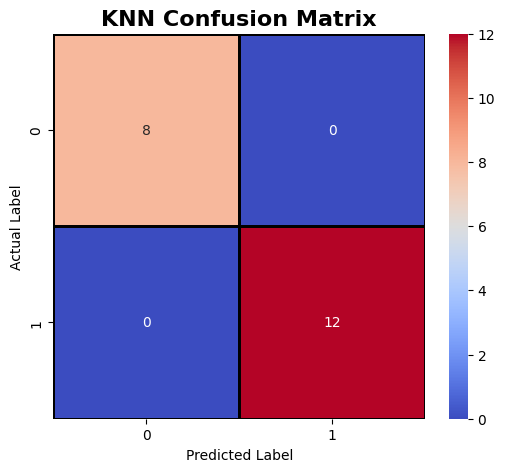

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, Y_train)

# Make predictions
knn_pred = knn.predict(X_test)

# Accuracy
print("KNN Accuracy:",
      accuracy_score(Y_test, knn_pred))

# Classification report
print("\nClassification Report:\n")
print(classification_report(Y_test, knn_pred))

# Confusion matrix
cm = confusion_matrix(Y_test, knn_pred)

# Visualize confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    linewidths=2,
    linecolor='black'
)

plt.title(
    "KNN Confusion Matrix",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

SVM Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



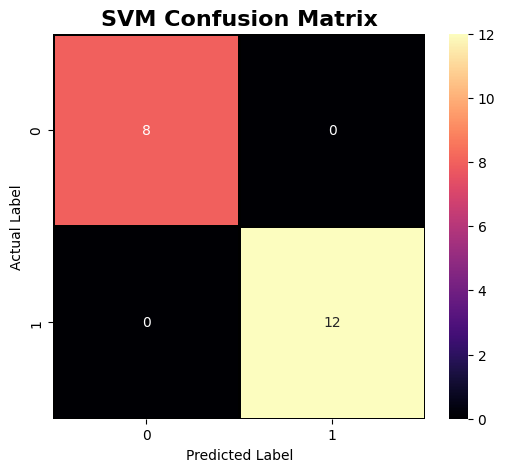

In [62]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
svm = SVC(kernel='rbf')

# Train model
svm.fit(X_train, Y_train)

# Make predictions
svm_pred = svm.predict(X_test)

# Accuracy
print("SVM Accuracy:",
      accuracy_score(Y_test, svm_pred))

# Classification report
print("\nClassification Report:\n")
print(classification_report(Y_test, svm_pred))

# Confusion matrix
cm = confusion_matrix(Y_test, svm_pred)

# Visualize confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma',
    linewidths=2,
    linecolor='black'
)

plt.title(
    "SVM Confusion Matrix",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Support Vector Machine (SVM) was used as a classification algorithm to predict whether students would pass or fail based on their academic performance and study behaviour. SVM works by finding the best boundary, also known as a hyperplane, that separates students into different classes.

The model was chosen because it performs well in classification problems and is effective at handling complex relationships between variables. In this study, SVM used factors such as attendance percentage, homework completion, study hours, and midterm scores to classify students accurately.

SVM is also useful because it focuses on maximizing the separation between classes, which helps improve prediction accuracy and reduce classification errors. The confusion matrix and evaluation metrics were used to assess the performance of the model on the testing dataset.

**CLASSIFICATION REPORT**

In [63]:
print(classification_report(Y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



**CONFUSION MATRIX**

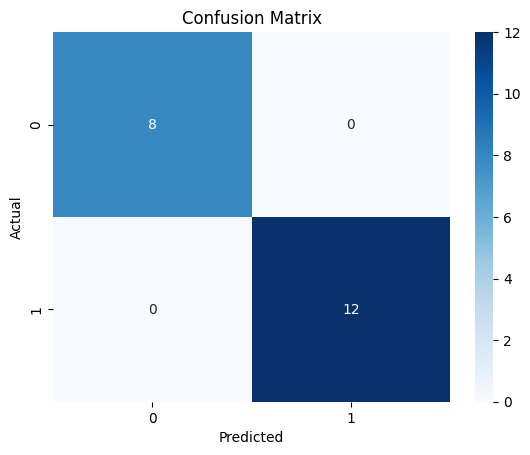

In [64]:
cm = confusion_matrix(Y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

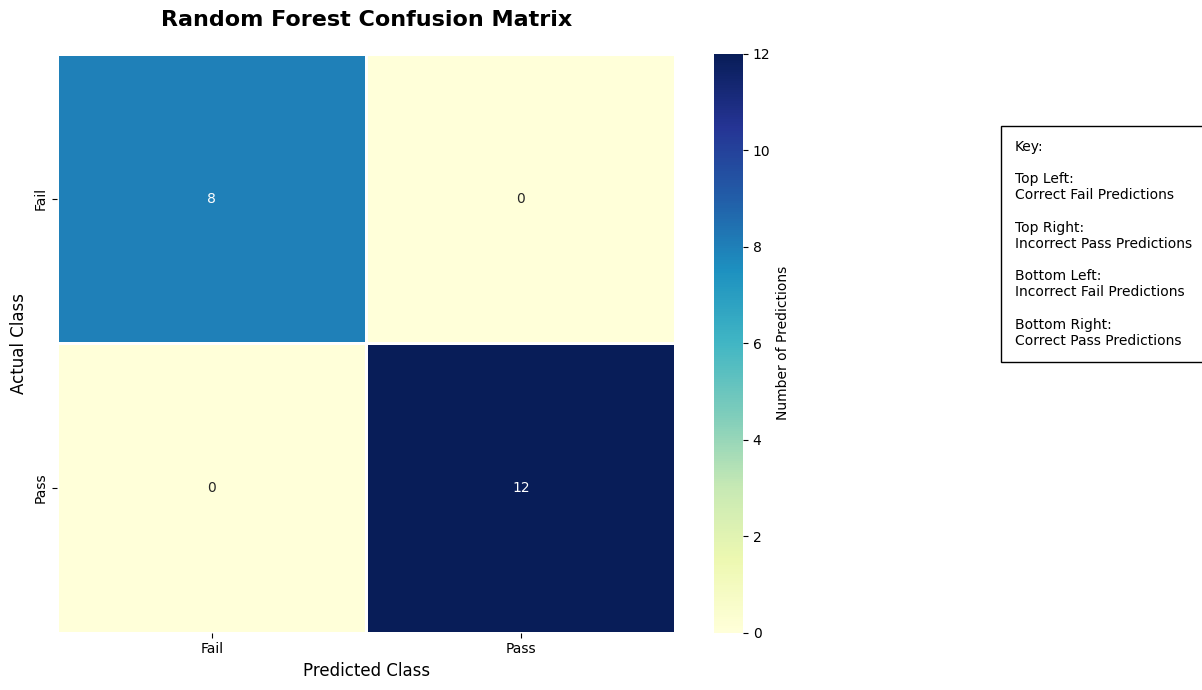

In [65]:
# Create confusion matrix
cm = confusion_matrix(Y_test, rf_pred)

# Labels
labels = ['Fail', 'Pass']

# Create figure
fig, ax = plt.subplots(figsize=(10,7))

# Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    linewidths=2,
    linecolor='white',
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Number of Predictions'},
    ax=ax
)

# Titles and labels
ax.set_title(
    'Random Forest Confusion Matrix',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('Actual Class', fontsize=12)

# Add key OUTSIDE figure
plt.figtext(
    1.02, 0.5,
    "Key:\n\n"
    "Top Left:\nCorrect Fail Predictions\n\n"
    "Top Right:\nIncorrect Pass Predictions\n\n"
    "Bottom Left:\nIncorrect Fail Predictions\n\n"
    "Bottom Right:\nCorrect Pass Predictions",
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black', pad=10)
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.show()

The confusion matrix is used to measure how well the Random Forest model predicted whether students would pass or fail. It compares the actual student results with the predictions made by the machine learning model. This helps show not only how many predictions were correct, but also whether the model made any mistakes.

In the matrix, the model correctly predicted 8 students who failed their courses. These are students who actually failed and were also predicted as failing by the model. The model also correctly predicted 12 students who passed their courses. These students actually passed and were also predicted as passing.

The confusion matrix also shows whether the model made any wrong predictions. In this case, there were no incorrect predictions at all. The value of 0 in the top-right section means that no student who failed was wrongly predicted as passing. Similarly, the value of 0 in the bottom-left section means that no student who passed was wrongly predicted as failing.

The darker coloured boxes in the matrix represent areas with higher numbers of correct predictions, while the lighter coloured boxes represent areas with few or no predictions. Since the incorrect prediction boxes are empty and contain values of 0, it shows that the model performed extremely well on the testing data.

These results suggest that the Random Forest model was very accurate and reliable in predicting student academic performance. The model was able to clearly identify patterns in the dataset using features such as attendance percentage, homework completion, study hours per week, and midterm scores. Based on the confusion matrix, the model successfully classified all students correctly without making any prediction errors.

Overall, the confusion matrix demonstrates that the Random Forest Classifier was highly effective for this study and performed better at distinguishing between students who passed and students who failed.


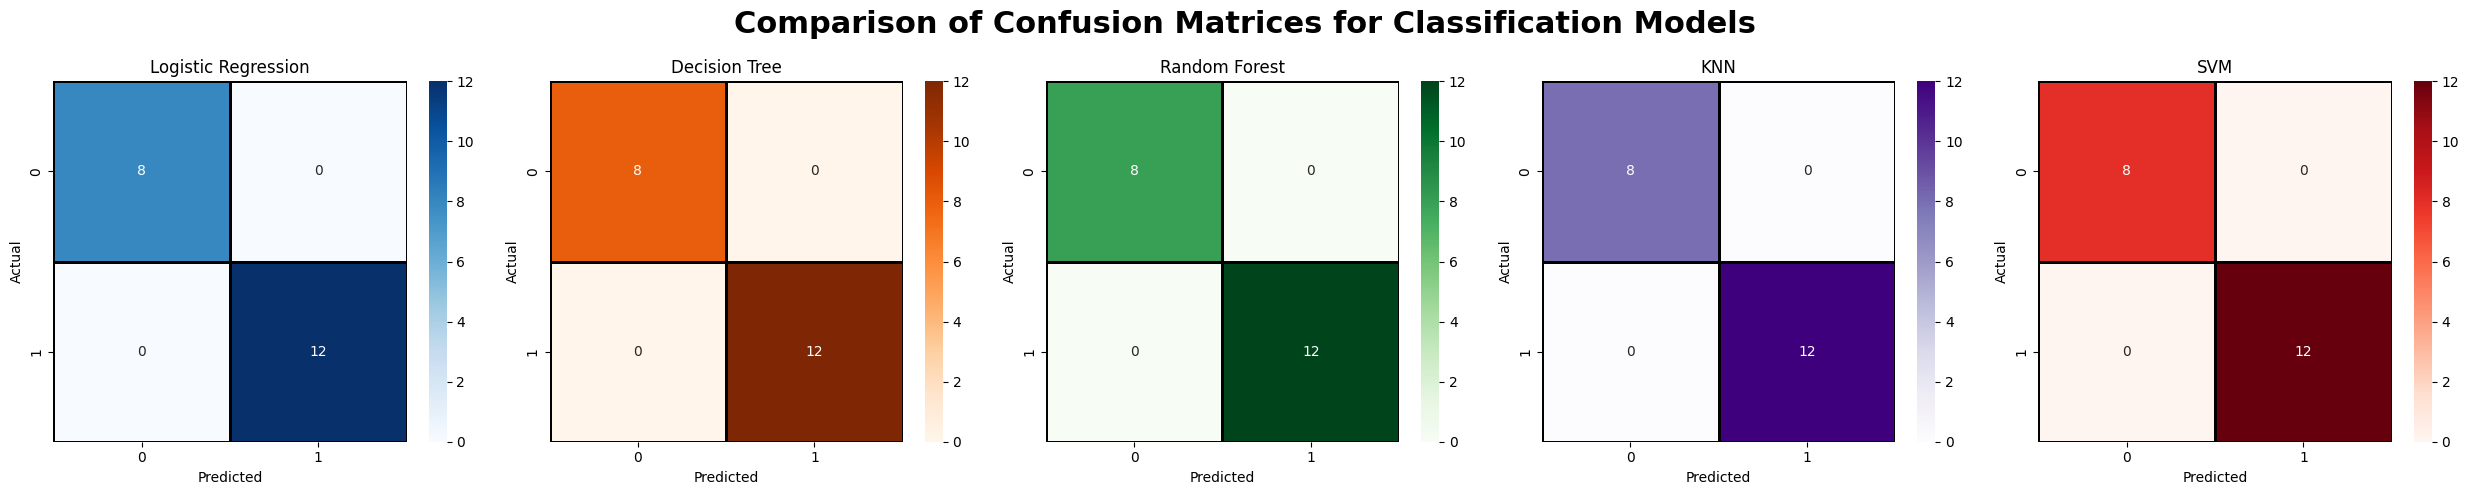

In [66]:
from sklearn.metrics import confusion_matrix

# Create confusion matrices
lr_cm = confusion_matrix(Y_test, lr_pred)
dt_cm = confusion_matrix(Y_test, dt_pred)
rf_cm = confusion_matrix(Y_test, rf_pred)
knn_cm = confusion_matrix(Y_test, knn_pred)
svm_cm = confusion_matrix(Y_test, svm_pred)

# Create figure
fig, axes = plt.subplots(1, 5, figsize=(25,5))

# Logistic Regression
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    linewidths=2,
    linecolor='black'
)
axes[0].set_title("Logistic Regression")

# Decision Tree
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[1],
    linewidths=2,
    linecolor='black'
)
axes[1].set_title("Decision Tree")

# Random Forest
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[2],
    linewidths=2,
    linecolor='black'
)
axes[2].set_title("Random Forest")

# KNN
sns.heatmap(
    knn_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    ax=axes[3],
    linewidths=2,
    linecolor='black'
)
axes[3].set_title("KNN")

# SVM
sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=axes[4],
    linewidths=2,
    linecolor='black'
)
axes[4].set_title("SVM")

# Labels
for ax in axes:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Main title
plt.suptitle(
    "Comparison of Confusion Matrices for Classification Models",
    fontsize=22,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

The confusion matrices produced by the different classification models showed very similar, and in some cases identical, prediction results. This indicates that the dataset contained strong and clear patterns that were easily identified by all the machine learning algorithms.

Factors such as attendance percentage, homework completion, study hours, and midterm scores showed strong relationships with student performance, making it easier for the models to distinguish between students who passed and those who failed.

Since the dataset was relatively clean and well-structured, the models achieved similar classification performance with very few or no prediction errors. This suggests that the selected features were highly effective predictors of academic success regardless of the classification algorithm used.

The similarity in results also demonstrates that multiple machine learning techniques can successfully predict student outcomes when the dataset contains strong predictive patterns.

**FEATURE IMPORTANCE**

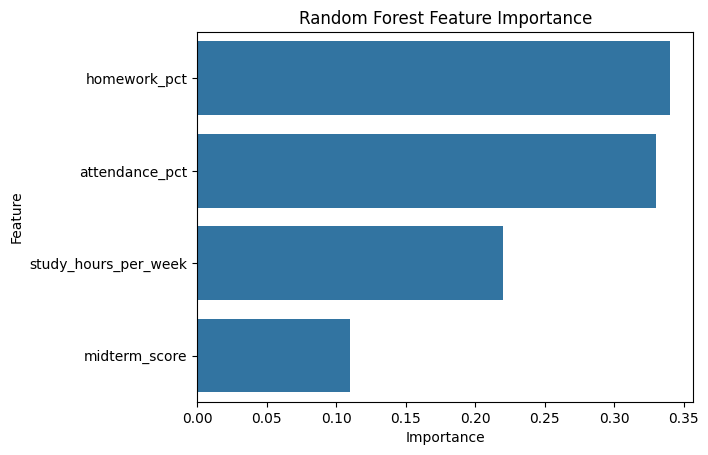

In [67]:
importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
    })

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
    )

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
    )

plt.title('Random Forest Feature Importance')
plt.show()

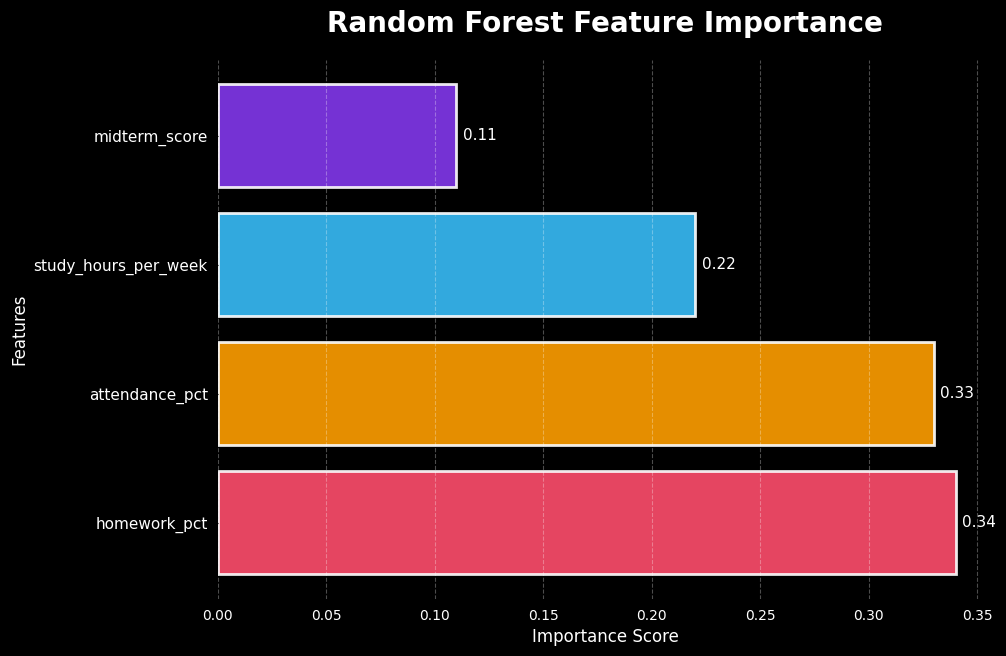

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importance
importance = rf.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Colors
colors = ['#ff4d6d', '#ff9e00', '#38bdf8', '#8338ec']

# Create figure
plt.figure(figsize=(10,7), facecolor='black')

ax = plt.gca()
ax.set_facecolor('black')

# Create bars
bars = plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors,
    edgecolor='white',
    linewidth=2
)

# Add glow effect
for bar in bars:
    bar.set_alpha(0.9)

# Add values
for index, value in enumerate(importance_df['Importance']):
    plt.text(
        value + 0.003,
        index,
        f"{value:.2f}",
        color='white',
        fontsize=11,
        va='center'
    )

# Titles
plt.title(
    "Random Forest Feature Importance",
    fontsize=20,
    color='white',
    fontweight='bold',
    pad=20
)

plt.xlabel(
    "Importance Score",
    fontsize=12,
    color='white'
)

plt.ylabel(
    "Features",
    fontsize=12,
    color='white'
)

# Customize ticks
plt.xticks(color='white')
plt.yticks(color='white', fontsize=11)

# Grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3,
    color='white'
)

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

The feature importance chart explains which factors the Random Forest model relied on the most when predicting whether a student would pass or fail. In simple terms, it shows which student behaviours had the biggest effect on academic success. Features with higher importance values had a stronger influence on the model’s predictions, while features with lower values had less influence.

Homework completion was the most important factor, with an importance value of 0.34. This means that homework played the biggest role in helping the model decide whether a student would pass or fail. Students who completed a higher percentage of their homework were much more likely to pass their courses. This suggests that consistent homework completion is strongly connected to better academic performance because it helps students practise, revise, and understand class materials more effectively.

Attendance percentage was the second most important feature, with a value of 0.33. This shows that students who attended classes regularly had a higher chance of passing. Regular attendance allows students to participate in lessons, understand explanations from teachers, and stay updated with course activities. Students with poor attendance were more likely to struggle academically and fail. The high importance value shows that attendance was almost as important as homework completion in predicting student success.

Study hours per week had an importance value of 0.22. This means that the amount of time students spent studying also affected their academic performance. Students who studied more hours each week generally performed better and were more likely to pass. Although study hours were not as influential as homework completion and attendance, they still contributed significantly to the model’s predictions. This indicates that consistent studying helps improve understanding, revision, and exam preparation.

Midterm score had the lowest importance value of 0.11. This means that midterm performance still affected the predictions, but it had less influence compared to the other features. One possible reason is that attendance, homework completion, and study habits already provided strong information about student behaviour and performance. Even though midterm scores were less important in the model, students with higher scores still had a greater chance of passing overall.

Overall, the chart clearly shows that student habits and academic behaviour were the strongest indicators of success. Students who regularly attended classes, completed their homework, and studied consistently were more likely to achieve positive academic outcomes. The Random Forest model used these features together to make accurate predictions about whether a student would pass or fail.

**FEATURE ENGINEERING**

**ATTENDANCE CATEGORY**

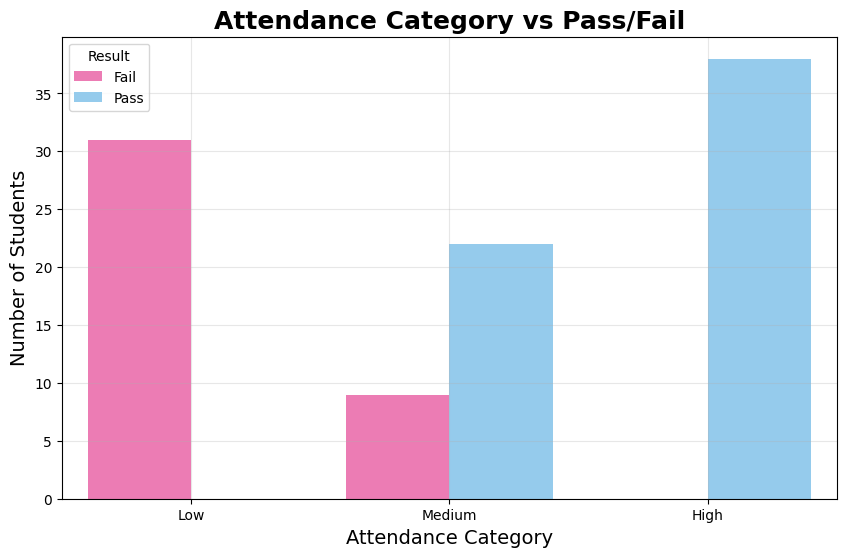

In [69]:
bins = [0, 60, 80, 101]
labels = ['Low', 'Medium', 'High']
df['attendance_category'] = pd.cut(df['attendance_pct'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10,6))

sns.countplot(
    x='attendance_category',
    hue='pass',
    data=df,
    palette=['#ff69b4', '#87cefa']
)

plt.title(
    "Attendance Category vs Pass/Fail",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Attendance Category", fontsize=14)
plt.ylabel("Number of Students", fontsize=14)

plt.legend(
    title='Result',
    labels=['Fail', 'Pass']
)

plt.grid(alpha=0.3)

plt.show()

The attendance category feature was created to group students based on their attendance percentages. Instead of using only numerical attendance values, students were divided into three simple groups: Low attendance, Medium attendance, and High attendance. This made the data easier to understand and helped show the relationship between attendance and academic performance more clearly.

Students with low attendance had the highest number of fail outcomes, showing that missing classes regularly can negatively affect academic performance. Students in the medium attendance category showed a mixture of pass and fail results, while students with high attendance had the highest number of pass outcomes.

The chart clearly shows that students who attended classes more regularly were more likely to pass their courses. Regular attendance helps students understand lessons better, participate in classroom activities, complete assignments properly, and stay updated with academic work.

Overall, the visualization demonstrates that attendance plays an important role in student success. The results suggest that improving class attendance may help increase student performance and reduce failure rates.

**STUDY EFFICIENCY RATIO**

In [70]:
# Create Study Efficiency Ratio

df['study_efficiency_ratio'] = (
    df['midterm_score'] /
    df['study_hours_per_week']
)

# View results
print(
    df[
        [
            'midterm_score',
            'study_hours_per_week',
            'study_efficiency_ratio'
        ]
    ].head()
)

   midterm_score  study_hours_per_week  study_efficiency_ratio
0             88                    12                7.333333
1             79                    10                7.900000
2             58                     4               14.500000
3             65                     6               10.833333
4             50                     3               16.666667


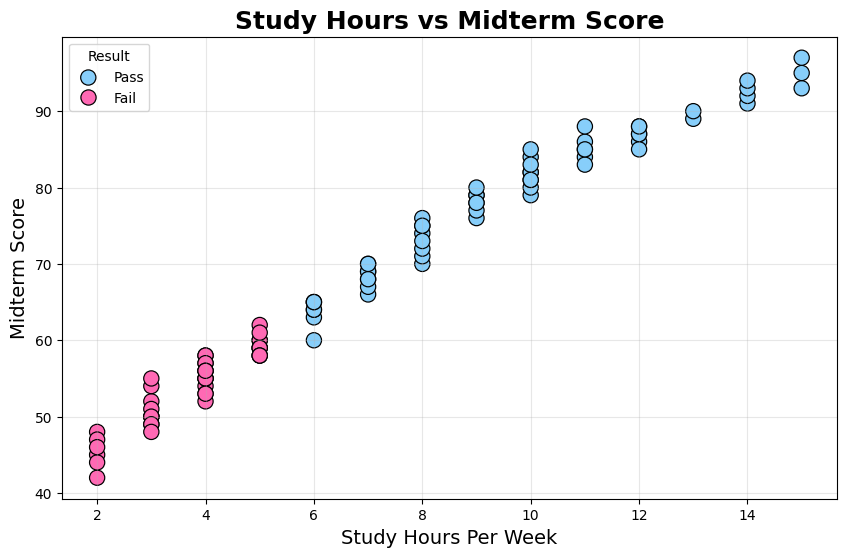

In [71]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='study_hours_per_week',
    y='midterm_score',
    hue='pass',
    data=df,
    palette=['#ff69b4', '#87cefa'],
    s=120,
    edgecolor='black'
)

plt.title(
    "Study Hours vs Midterm Score",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Study Hours Per Week",
    fontsize=14
)

plt.ylabel(
    "Midterm Score",
    fontsize=14
)

plt.legend(
    title='Result',
    labels=['Pass', 'Fail']
)

plt.grid(alpha=0.3)

plt.show()

The scatterplot shows the connection between the number of hours students studied each week and their midterm scores. Each dot represents one student. The colours help separate students who passed from students who failed.

The graph shows that students who studied for more hours usually achieved higher midterm scores. Students who failed mostly studied for fewer hours and had lower scores, while students who passed generally studied more and achieved better results.

There is a clear upward pattern in the graph, which means that as study hours increased, midterm scores also increased. This suggests that studying regularly and spending more time revising can improve academic performance.

Overall, the scatterplot shows that study habits play an important role in student success. Students who studied more consistently were more likely to get higher scores and pass their courses.

**OVERALL PERFOMANCE SCORE**

In [72]:
# Create Overall Performance Score

df['overall_performance_score'] = (
    df['attendance_pct'] +
    df['homework_pct'] +
    df['midterm_score'] +
    df['study_hours_per_week']
) / 4

# View results
print(
    df[
        [
            'attendance_pct',
            'homework_pct',
            'midterm_score',
            'study_hours_per_week',
            'overall_performance_score'
        ]
    ].head()
)

   attendance_pct  homework_pct  midterm_score  study_hours_per_week  \
0              95            92             88                    12   
1              88            85             79                    10   
2              60            55             58                     4   
3              72            70             65                     6   
4              40            45             50                     3   

   overall_performance_score  
0                      71.75  
1                      65.50  
2                      44.25  
3                      53.25  
4                      34.50  


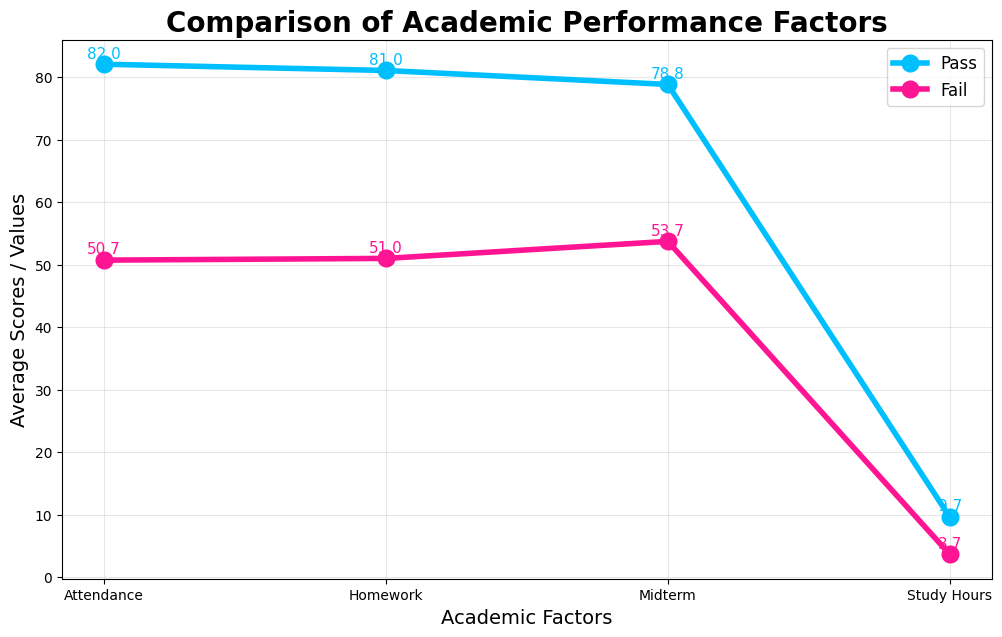

In [73]:
plt.figure(figsize=(12,7))

# Pass students average
pass_avg = df[df['pass'] == 1][[
    'attendance_pct',
    'homework_pct',
    'midterm_score',
    'study_hours_per_week'
]].mean()

# Fail students average
fail_avg = df[df['pass'] == 0][[
    'attendance_pct',
    'homework_pct',
    'midterm_score',
    'study_hours_per_week'
]].mean()

# Features
features = [
    'Attendance',
    'Homework',
    'Midterm',
    'Study Hours'
]

# Plot lines
plt.plot(
    features,
    pass_avg,
    marker='o',
    markersize=12,
    linewidth=4,
    color='deepskyblue',
    label='Pass'
)

plt.plot(
    features,
    fail_avg,
    marker='o',
    markersize=12,
    linewidth=4,
    color='deeppink',
    label='Fail'
)

# Add values
for i, value in enumerate(pass_avg):
    plt.text(i, value+1, f"{value:.1f}",
             color='deepskyblue',
             fontsize=11,
             ha='center')

for i, value in enumerate(fail_avg):
    plt.text(i, value+1, f"{value:.1f}",
             color='deeppink',
             fontsize=11,
             ha='center')

# Titles
plt.title(
    "Comparison of Academic Performance Factors",
    fontsize=20,
    fontweight='bold'
)

plt.ylabel(
    "Average Scores / Values",
    fontsize=14
)

plt.xlabel(
    "Academic Factors",
    fontsize=14
)

plt.legend(fontsize=12)

plt.grid(alpha=0.3)

plt.show()

The line graph compares the average academic performance of students who passed and students who failed across four factors: attendance, homework completion, midterm scores, and study hours. The blue line represents students who passed, while the pink line represents students who failed.

The graph clearly shows that students who passed had higher values in all academic factors compared to students who failed. Passing students had higher attendance percentages, completed more homework, achieved better midterm scores, and studied for more hours each week.

Students who failed had noticeably lower averages across all factors. Their attendance was lower, homework completion was lower, midterm scores were lower, and they also spent fewer hours studying.

The biggest difference can be seen in study hours and midterm scores, showing that students who studied more consistently generally performed better in their exams and were more likely to pass.

Overall, the graph demonstrates that strong academic habits, such as attending classes regularly, completing homework, and studying consistently, are closely linked to better academic performance and successful outcomes.

**NOTE** - The drop in the line for study hours does not indicate poorer performance. It occurs because study hours are measured on a smaller numerical scale compared to attendance, homework, and midterm scores, which are percentages out of 100. Although the study hours values appear lower on the graph, students who passed still studied more hours on average than students who failed.